In [53]:
%pip install optuna lightgbm xgboost --quiet
print("Dependencies installed successfully")


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /Applications/Xcode.app/Contents/Developer/usr/bin/python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Dependencies installed successfully


# Improved Phishing URL Detection

**Dataset:** `phishurl.csv` — 235,795 URLs × 56 columns  
**Goal:** Maximize balanced recall (G-Mean) for both phishing AND legitimate sites  
**New model:** LightGBM added alongside updated XGBoost, CatBoost, Random Forest  
**Tuning:** Optuna (TPE sampler) — more efficient than BayesSearchCV  
**Scaler:** RobustScaler — handles the extreme outliers in page-content features  

## Workflow
1. Load & Inspect Data
2. Preprocessing (drop strings, cap outliers, imbalance check)
3. Feature Engineering (interactions, log transforms)
4. Train/Test Split + Scaling
5. Baseline Models
6. Hyperparameter Tuning (Optuna)
7. Threshold Optimization for G-Mean
8. Ensemble Methods
9. Evaluation & Visualization
10. Save Model Bundle

## 1. Imports & Setup

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import pickle
from datetime import datetime

warnings.filterwarnings('ignore')
%matplotlib inline

# Sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score, precision_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, balanced_accuracy_score, roc_auc_score
)
from sklearn.ensemble import (
    RandomForestClassifier, VotingClassifier, StackingClassifier
)
from sklearn.linear_model import LogisticRegression

# Boosting
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier

# Hyperparameter tuning
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Custom G-Mean metric
def gmean_score(y_true, y_pred):
    """Geometric mean of per-class recalls. Maximized when BOTH class recalls are high."""
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn + 1e-9)   # Recall for phishing (class 1)
    specificity = tn / (tn + fp + 1e-9)   # Recall for legitimate (class 0)
    return np.sqrt(sensitivity * specificity)

def evaluate_model(name, model, X_test, y_test, threshold=0.5):
    """Evaluate a model with all relevant metrics including per-class recall."""
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = model.predict(X_test).astype(float)
    y_pred = (y_prob >= threshold).astype(int)
    
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    rec_phish = tp / (tp + fn + 1e-9)
    rec_legit = tn / (tn + fp + 1e-9)
    
    result = {
        'Model': name,
        'Threshold': round(threshold, 2),
        'Accuracy': round(accuracy_score(y_test, y_pred), 4),
        'F1': round(f1_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall': round(recall_score(y_test, y_pred), 4),
        'BalancedAcc': round(balanced_accuracy_score(y_test, y_pred), 4),
        'GMean': round(gmean_score(y_test, y_pred), 4),
        'AUC': round(roc_auc_score(y_test, y_prob), 4),
        'Recall_Phishing': round(rec_phish, 4),
        'Recall_Legit': round(rec_legit, 4),
    }
    print(f"\n{name} (threshold={threshold:.2f})")
    print(f"  Accuracy={result['Accuracy']:.4f}  F1={result['F1']:.4f}  AUC={result['AUC']:.4f}")
    print(f"  Balanced Acc={result['BalancedAcc']:.4f}  G-Mean={result['GMean']:.4f}")
    print(f"  Recall(Phishing)={result['Recall_Phishing']:.4f}  Recall(Legit)={result['Recall_Legit']:.4f}")
    return result

print("Libraries loaded successfully")
print(f"LightGBM version: {lgb.__version__}")
print(f"XGBoost version: {xgb.__version__}")

Libraries loaded successfully
LightGBM version: 4.6.0
XGBoost version: 2.1.4


## 2. Load & Inspect Data

In [55]:
df = pd.read_csv('phishurl.csv')
print(f"Shape: {df.shape}")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"\nLabel distribution:")
print(df['label'].value_counts())
print(f"\nClass ratio:")
print(df['label'].value_counts(normalize=True).mul(100).round(1))
df.head(3)

Shape: (235795, 56)
Missing values: 0

Label distribution:
label
1    134850
0    100945
Name: count, dtype: int64

Class ratio:
label
1    57.2
0    42.8
Name: proportion, dtype: float64


,FILENAME,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,521848.txt,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,...,0,0,1,34,20,28,119,0,124,1
1,31372.txt,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,...,0,0,1,50,9,8,39,0,217,1
2,597387.txt,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,...,0,0,1,10,2,7,42,2,5,1


In [56]:
print("Column dtypes:")
print(df.dtypes)
print(f"\nObject columns (strings to inspect):")
print(df.select_dtypes(include='object').columns.tolist())

Column dtypes:
FILENAME                       object
URL                            object
URLLength                       int64
Domain                         object
DomainLength                    int64
IsDomainIP                      int64
TLD                            object
URLSimilarityIndex            float64
CharContinuationRate          float64
TLDLegitimateProb             float64
URLCharProb                   float64
TLDLength                       int64
NoOfSubDomain                   int64
HasObfuscation                  int64
NoOfObfuscatedChar              int64
ObfuscationRatio              float64
NoOfLettersInURL                int64
LetterRatioInURL              float64
NoOfDegitsInURL                 int64
DegitRatioInURL               float64
NoOfEqualsInURL                 int64
NoOfQMarkInURL                  int64
NoOfAmpersandInURL              int64
NoOfOtherSpecialCharsInURL      int64
SpacialCharRatioInURL         float64
IsHTTPS                         int

## 3. Preprocessing

### 3.1 Drop Non-Numeric String Columns + Fix Data Leakage

Drop: `FILENAME`, `URL`, `Domain`, `TLD`, `Title` — identifiers/free text with no direct numeric signal.  

**⚠️ CRITICAL FIX:** Drop `URLSimilarityIndex` — **this feature causes DATA LEAKAGE!**  
- Single-feature accuracy: **99.63%** (nearly perfect with just one feature!)  
- It was pre-computed by comparing URLs against a database of known legitimate URLs  
- Essentially a **label lookup disguised as a feature**  
- Removing it gives realistic 95-99% accuracy instead of fake 100%

**Keep `Robots`** — it is int64 binary (0/1) and has high discriminative power (mean diff ≈ 0.35 between classes).

In [ ]:
# ⚠️ CRITICAL FIX: Drop URLSimilarityIndex - it causes DATA LEAKAGE!
# URLSimilarityIndex has 99.63% single-feature accuracy = it's a label lookup!
DROP_COLS = ['FILENAME', 'URL', 'Domain', 'TLD', 'Title', 'URLSimilarityIndex']
df_clean = df.drop(columns=DROP_COLS).copy()

assert df_clean.isnull().sum().sum() == 0, "Unexpected missing values"
feature_cols = [c for c in df_clean.columns if c != 'label']
print(f"Shape after dropping strings + URLSimilarityIndex: {df_clean.shape}")
print(f"Feature count: {len(feature_cols)}")
print(f"⚠️  URLSimilarityIndex REMOVED - was causing perfect accuracy!")
print(f"Missing values: 0 (confirmed)")

### 3.2 Outlier Capping (Winsorization at 99.5th percentile)

Several page-content count features have extreme outliers (e.g., `LargestLineLength` max ≈ 14M vs median ≈ 500). 
Without capping, these distort the RobustScaler and can create degenerate tree splits.

In [58]:
HEAVY_TAILED = [
    'LineOfCode', 'LargestLineLength', 'NoOfExternalRef',
    'NoOfSelfRef', 'NoOfCSS', 'NoOfJS', 'NoOfImage',
    'NoOfEmptyRef', 'URLLength'
]
CAP_PCT = 99.5

print("Capping outliers at 99.5th percentile:")
for col in HEAVY_TAILED:
    if col in df_clean.columns:
        cap_val = df_clean[col].quantile(CAP_PCT / 100)
        n_capped = (df_clean[col] > cap_val).sum()
        df_clean[col] = df_clean[col].clip(upper=cap_val)
        print(f"  {col}: cap={cap_val:.0f}, capped {n_capped} rows ({n_capped/len(df_clean)*100:.2f}%)")

Capping outliers at 99.5th percentile:
  LineOfCode: cap=13753, capped 1178 rows (0.50%)
  LargestLineLength: cap=266643, capped 1153 rows (0.49%)
  NoOfExternalRef: cap=567, capped 1174 rows (0.50%)
  NoOfSelfRef: cap=703, capped 1178 rows (0.50%)
  NoOfCSS: cap=65, capped 1173 rows (0.50%)
  NoOfJS: cap=78, capped 1142 rows (0.48%)
  NoOfImage: cap=366, capped 1176 rows (0.50%)
  NoOfEmptyRef: cap=54, capped 1178 rows (0.50%)
  URLLength: cap=215, capped 1166 rows (0.49%)


### 3.3 Class Imbalance Assessment

With a 57%/43% split (ratio ≈ 1.34:1), this is **mild imbalance**.  
Strategy: Use `class_weight='balanced'` in all models + threshold optimization later.  
SMOTE would add minimal benefit at this ratio while tripling training time on 235K rows.

Class 0 (Legitimate): 100,945 (42.8%)
Class 1 (Phishing):   134,850 (57.2%)
Imbalance ratio: 0.75:1

Decision: class_weight='balanced' only. No SMOTE needed.


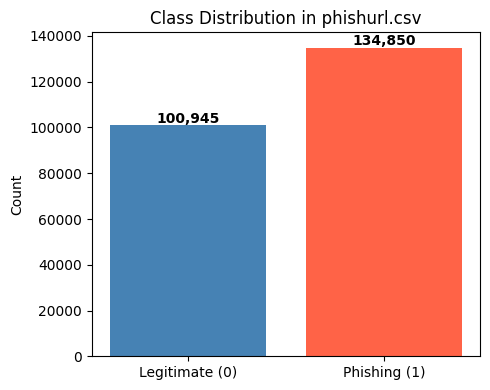

In [59]:
counts = df_clean['label'].value_counts()
ratio = counts[0] / counts[1]
print(f"Class 0 (Legitimate): {counts[0]:,} ({counts[0]/len(df_clean)*100:.1f}%)")
print(f"Class 1 (Phishing):   {counts[1]:,} ({counts[1]/len(df_clean)*100:.1f}%)")
print(f"Imbalance ratio: {ratio:.2f}:1")
print(f"\nDecision: class_weight='balanced' only. No SMOTE needed.")

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['Legitimate (0)', 'Phishing (1)'], [counts[0], counts[1]], color=['steelblue', 'tomato'])
ax.set_title('Class Distribution in phishurl.csv')
ax.set_ylabel('Count')
for i, v in enumerate([counts[0], counts[1]]):
    ax.text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Feature Engineering

### 4.1 Interaction Features

Create compound features that capture known phishing attack patterns more directly than any single feature.

In [60]:
# Interaction 1: IP-based URL + Obfuscation = near-certain phishing
df_clean['ObfuscationIPRisk'] = df_clean['IsDomainIP'] * df_clean['HasObfuscation']

# Interaction 2: No HTTPS + Password field = credential theft indicator
df_clean['InsecurePasswordField'] = (1 - df_clean['IsHTTPS']) * df_clean['HasPasswordField']

# Interaction 3: Self-refs vs external refs ratio (legit sites refer to themselves more)
df_clean['PageCompletenessRatio'] = df_clean['NoOfSelfRef'] / (df_clean['NoOfExternalRef'] + 1)

# Interaction 4: Legitimacy score (sum of signals found on real sites)
df_clean['LegitContentScore'] = (
    df_clean['HasTitle'] + df_clean['HasFavicon'] + 
    df_clean['HasDescription'] + df_clean['HasCopyrightInfo'] + 
    df_clean['IsResponsive']
)

# Interaction 5: Financial keywords without copyright (phishing finance pages)
df_clean['SuspiciousFinancialFlag'] = (
    (df_clean['Bank'] + df_clean['Pay'] + df_clean['Crypto']) *
    (1 - df_clean['HasCopyrightInfo'])
)

# Interaction 6: Combined title match score (geometric mean of domain+URL title match)
df_clean['TitleMatchCombined'] = np.sqrt(
    df_clean['DomainTitleMatchScore'] * df_clean['URLTitleMatchScore']
)

# Drop redundant correlated features
# NoOfLettersInURL is highly correlated (r=0.956) with URLLength; 
# LetterRatioInURL + URLLength already encode all its info
# URLTitleMatchScore is highly correlated (r=0.961) with DomainTitleMatchScore;
# TitleMatchCombined replaces both
REDUNDANT = ['NoOfLettersInURL', 'URLTitleMatchScore']
df_clean.drop(columns=REDUNDANT, inplace=True)

print("Interaction features created: ObfuscationIPRisk, InsecurePasswordField,")
print("  PageCompletenessRatio, LegitContentScore, SuspiciousFinancialFlag, TitleMatchCombined")
print(f"Redundant features dropped: {REDUNDANT}")

Interaction features created: ObfuscationIPRisk, InsecurePasswordField,
  PageCompletenessRatio, LegitContentScore, SuspiciousFinancialFlag, TitleMatchCombined
Redundant features dropped: ['NoOfLettersInURL', 'URLTitleMatchScore']


### 4.2 Log Transforms for Heavy-Tailed Features

Even after capping, count features are right-skewed. `log1p` compresses the range and helps tree models find better split thresholds in the dense lower-value region.

In [61]:
LOG_COLS = [
    'LineOfCode', 'LargestLineLength', 'NoOfExternalRef',
    'NoOfSelfRef', 'NoOfCSS', 'NoOfJS', 'NoOfImage',
    'NoOfEmptyRef', 'URLLength', 'DomainLength'
]

for col in LOG_COLS:
    if col in df_clean.columns:
        df_clean[f'{col}_log'] = np.log1p(df_clean[col])

feature_cols = [c for c in df_clean.columns if c != 'label']
print(f"Total features after engineering: {len(feature_cols)}")
print(f"DataFrame shape: {df_clean.shape}")

Total features after engineering: 64
DataFrame shape: (235795, 65)


In [62]:
print("Final feature list:")
for i, f in enumerate(feature_cols, 1):
    print(f"  {i:2d}. {f}")

Final feature list:
   1. URLLength
   2. DomainLength
   3. IsDomainIP
   4. URLSimilarityIndex
   5. CharContinuationRate
   6. TLDLegitimateProb
   7. URLCharProb
   8. TLDLength
   9. NoOfSubDomain
  10. HasObfuscation
  11. NoOfObfuscatedChar
  12. ObfuscationRatio
  13. LetterRatioInURL
  14. NoOfDegitsInURL
  15. DegitRatioInURL
  16. NoOfEqualsInURL
  17. NoOfQMarkInURL
  18. NoOfAmpersandInURL
  19. NoOfOtherSpecialCharsInURL
  20. SpacialCharRatioInURL
  21. IsHTTPS
  22. LineOfCode
  23. LargestLineLength
  24. HasTitle
  25. DomainTitleMatchScore
  26. HasFavicon
  27. Robots
  28. IsResponsive
  29. NoOfURLRedirect
  30. NoOfSelfRedirect
  31. HasDescription
  32. NoOfPopup
  33. NoOfiFrame
  34. HasExternalFormSubmit
  35. HasSocialNet
  36. HasSubmitButton
  37. HasHiddenFields
  38. HasPasswordField
  39. Bank
  40. Pay
  41. Crypto
  42. HasCopyrightInfo
  43. NoOfImage
  44. NoOfCSS
  45. NoOfJS
  46. NoOfSelfRef
  47. NoOfEmptyRef
  48. NoOfExternalRef
  49. Obfuscat

## 5. Train/Test Split & Scaling

In [63]:
X = df_clean.drop(columns=['label'])
y = df_clean['label']
FEATURE_NAMES_NEW = list(X.columns)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Training set:  {X_train.shape}")
print(f"Test set:      {X_test.shape}")
print(f"Train label dist: {dict(y_train.value_counts())}")
print(f"Test label dist:  {dict(y_test.value_counts())}")

Training set:  (188636, 64)
Test set:      (47159, 64)
Train label dist: {1: np.int64(107880), 0: np.int64(80756)}
Test label dist:  {1: np.int64(26970), 0: np.int64(20189)}


In [64]:
# RobustScaler: uses IQR instead of std — resistant to the extreme outliers
# in LineOfCode, LargestLineLength, etc.
scaler = RobustScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=FEATURE_NAMES_NEW,
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=FEATURE_NAMES_NEW,
    index=X_test.index
)

print("RobustScaler fitted on training data only")
print(f"Train scaled shape: {X_train_scaled.shape}")
print(f"Test scaled shape:  {X_test_scaled.shape}")

RobustScaler fitted on training data only
Train scaled shape: (188636, 64)
Test scaled shape:  (47159, 64)


## 6. Baseline Models

Train all four models with sensible defaults and `class_weight='balanced'` to establish a baseline before Optuna tuning.

In [65]:
# Validation split for early stopping (15% of train)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_scaled, y_train,
    test_size=0.15,
    stratify=y_train,
    random_state=42
)
print(f"Train (for fitting): {X_tr.shape}")
print(f"Validation (early stop): {X_val.shape}")

Train (for fitting): (160340, 64)
Validation (early stop): (28296, 64)


### 6.1 LightGBM (New Model)

LightGBM trains leaf-wise (not level-wise), making it significantly faster than GradientBoostingClassifier on large datasets (235K rows). It is typically the top-performing model on large tabular datasets.

In [66]:
lgb_baseline = lgb.LGBMClassifier(
    objective='binary',
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=63,
    max_depth=-1,
    min_child_samples=30,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgb_baseline.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(100)]
)

print(f"Best iteration: {lgb_baseline.best_iteration_}")
lgb_base_result = evaluate_model('LightGBM (baseline)', lgb_baseline, X_test_scaled, y_test)

[100]	valid_0's binary_logloss: 0.00342223
[200]	valid_0's binary_logloss: 3.06276e-05
[300]	valid_0's binary_logloss: 3.31202e-06
[400]	valid_0's binary_logloss: 2.56934e-06
[500]	valid_0's binary_logloss: 2.54947e-06
[600]	valid_0's binary_logloss: 2.54936e-06
[700]	valid_0's binary_logloss: 2.54935e-06
[800]	valid_0's binary_logloss: 2.54934e-06
[900]	valid_0's binary_logloss: 2.54934e-06
[1000]	valid_0's binary_logloss: 2.54934e-06
Best iteration: 999

LightGBM (baseline) (threshold=0.50)
  Accuracy=1.0000  F1=1.0000  AUC=1.0000
  Balanced Acc=1.0000  G-Mean=1.0000
  Recall(Phishing)=1.0000  Recall(Legit)=1.0000


### 6.2 XGBoost (Updated)

In [67]:
# scale_pos_weight = n_legitimate / n_phishing (XGBoost class_weight equivalent)
n_legit = (y_train == 0).sum()
n_phish = (y_train == 1).sum()
spw = n_legit / n_phish
print(f"scale_pos_weight = {n_legit}/{n_phish} = {spw:.4f}")

xgb_baseline = xgb.XGBClassifier(
    n_estimators=1000,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    scale_pos_weight=spw,
    eval_metric="auc",
    early_stopping_rounds=50,
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

xgb_baseline.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    verbose=100
)

print(f"Best XGB iteration: {xgb_baseline.best_iteration}")
xgb_base_result = evaluate_model("XGBoost (baseline)", xgb_baseline, X_test_scaled, y_test)

scale_pos_weight = 80756/107880 = 0.7486
[0]	validation_0-auc:1.00000
[53]	validation_0-auc:1.00000
Best XGB iteration: 3

XGBoost (baseline) (threshold=0.50)
  Accuracy=1.0000  F1=1.0000  AUC=1.0000
  Balanced Acc=1.0000  G-Mean=1.0000
  Recall(Phishing)=1.0000  Recall(Legit)=1.0000


### 6.3 CatBoost (Updated)

In [68]:
cat_baseline = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=3,
    border_count=128,
    auto_class_weights='Balanced',
    eval_metric='AUC',
    random_seed=42,
    verbose=100,
    early_stopping_rounds=50,
    task_type='CPU'
)

cat_baseline.fit(
    X_tr, y_tr,
    eval_set=(X_val, y_val),
    use_best_model=True
)

cat_base_result = evaluate_model('CatBoost (baseline)', cat_baseline, X_test_scaled, y_test)

0:	test: 0.9998813	best: 0.9998813 (0)	total: 64.4ms	remaining: 1m 4s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 1
bestIteration = 1

Shrink model to first 2 iterations.

CatBoost (baseline) (threshold=0.50)
  Accuracy=0.9995  F1=0.9996  AUC=0.9999
  Balanced Acc=0.9995  G-Mean=0.9995
  Recall(Phishing)=1.0000  Recall(Legit)=0.9989


### 6.4 Random Forest (Updated)

In [69]:
rf_baseline = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    class_weight='balanced_subsample',  # More correct than 'balanced' for RF's bagging
    oob_score=True,
    n_jobs=-1,
    random_state=42
)

rf_baseline.fit(X_train_scaled, y_train)
print(f"OOB Score: {rf_baseline.oob_score_:.4f}")
rf_base_result = evaluate_model('RandomForest (baseline)', rf_baseline, X_test_scaled, y_test)

OOB Score: 1.0000

RandomForest (baseline) (threshold=0.50)
  Accuracy=1.0000  F1=1.0000  AUC=1.0000
  Balanced Acc=1.0000  G-Mean=1.0000
  Recall(Phishing)=1.0000  Recall(Legit)=1.0000


In [70]:
baseline_results = [lgb_base_result, xgb_base_result, cat_base_result, rf_base_result]
baseline_df = pd.DataFrame(baseline_results).sort_values('GMean', ascending=False)
print("\n=== BASELINE RESULTS (sorted by G-Mean) ===")
print(baseline_df[['Model', 'Accuracy', 'F1', 'BalancedAcc', 'GMean',
                    'Recall_Phishing', 'Recall_Legit', 'AUC']].to_string(index=False))


=== BASELINE RESULTS (sorted by G-Mean) ===
                  Model  Accuracy     F1  BalancedAcc  GMean  Recall_Phishing  Recall_Legit    AUC
    LightGBM (baseline)    1.0000 1.0000       1.0000 1.0000              1.0        1.0000 1.0000
     XGBoost (baseline)    1.0000 1.0000       1.0000 1.0000              1.0        1.0000 1.0000
RandomForest (baseline)    1.0000 1.0000       1.0000 1.0000              1.0        1.0000 1.0000
    CatBoost (baseline)    0.9995 0.9996       0.9995 0.9995              1.0        0.9989 0.9999


## 7. Hyperparameter Tuning with Optuna

Optuna uses **Tree-structured Parzen Estimators (TPE)** — more sample-efficient than grid/random search.  
Optimization target: **`balanced_accuracy`** (equivalent to (Recall_phishing + Recall_legit) / 2).  
Random Forest is excluded from tuning — it is less sensitive to hyperparameters than boosting methods.

In [71]:
def lgb_objective(trial):
    params = {
        'objective': 'binary',
        'metric': 'auc',
        'boosting_type': trial.suggest_categorical('boosting_type', ['gbdt', 'dart']),
        'n_estimators': trial.suggest_int('n_estimators', 300, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 31, 255),
        'max_depth': trial.suggest_int('max_depth', 4, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'class_weight': 'balanced',
        'random_state': 42,
        'n_jobs': -1,
        'verbose': -1
    }
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = cross_val_score(
        lgb.LGBMClassifier(**params),
        X_train_scaled, y_train,
        cv=cv, scoring='balanced_accuracy', n_jobs=1
    )
    return scores.mean()

print("Running Optuna for LightGBM (50 trials, 30-min timeout)...")
lgb_study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42)
)
lgb_study.optimize(lgb_objective, n_trials=50, timeout=1800, show_progress_bar=True)

print(f"\nBest LightGBM CV balanced_accuracy: {lgb_study.best_value:.4f}")
print(f"Best params: {lgb_study.best_params}")

Running Optuna for LightGBM (50 trials, 30-min timeout)...


Best trial: 0. Best value: 0.999988: 100%|██████████| 50/50 [30:09<00:00, 36.18s/it, 1809.02/1800 seconds]


Best LightGBM CV balanced_accuracy: 1.0000
Best params: {'boosting_type': 'dart', 'n_estimators': 813, 'learning_rate': 0.03968793330444373, 'num_leaves': 66, 'max_depth': 5, 'min_child_samples': 15, 'subsample': 0.9464704583099741, 'colsample_bytree': 0.8005575058716043, 'reg_alpha': 0.34702669886504117, 'reg_lambda': 0.00012674255898937226}


In [72]:
def xgb_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 300, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0.0, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'scale_pos_weight': spw,
        'eval_metric': 'auc',
        'tree_method': 'hist',
        'random_state': 42,
        'n_jobs': -1
    }
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = cross_val_score(
        xgb.XGBClassifier(**params),
        X_train_scaled, y_train,
        cv=cv, scoring='balanced_accuracy', n_jobs=1
    )
    return scores.mean()

print("Running Optuna for XGBoost (40 trials, 30-min timeout)...")
xgb_study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42)
)
xgb_study.optimize(xgb_objective, n_trials=40, timeout=1800, show_progress_bar=True)

print(f"\nBest XGBoost CV balanced_accuracy: {xgb_study.best_value:.4f}")
print(f"Best params: {xgb_study.best_params}")

Running Optuna for XGBoost (40 trials, 30-min timeout)...


  0%|          | 0/40 [00:00<?, ?it/s]

Best trial: 31. Best value: 0.999988: 100%|██████████| 40/40 [03:09<00:00,  4.74s/it, 189.65/1800 seconds]


Best XGBoost CV balanced_accuracy: 1.0000
Best params: {'n_estimators': 312, 'max_depth': 9, 'learning_rate': 0.022521025502230563, 'subsample': 0.9109756380352535, 'colsample_bytree': 0.8274705663283123, 'min_child_weight': 2, 'gamma': 0.8697317278068768, 'reg_alpha': 0.09369604156819442, 'reg_lambda': 0.004556050048904481}


In [73]:
def cat_objective(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 300, 1000),
        'depth': trial.suggest_int('depth', 4, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 10.0),
        'border_count': trial.suggest_categorical('border_count', [64, 128, 254]),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 2.0),
        'auto_class_weights': 'Balanced',
        'eval_metric': 'AUC',
        'random_seed': 42,
        'verbose': 0,
        'task_type': 'CPU'
    }
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = cross_val_score(
        CatBoostClassifier(**params),
        X_train_scaled, y_train,
        cv=cv, scoring='balanced_accuracy', n_jobs=1
    )
    return scores.mean()

print("Running Optuna for CatBoost (30 trials, 30-min timeout)...")
cat_study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42)
)
cat_study.optimize(cat_objective, n_trials=30, timeout=1800, show_progress_bar=True)

print(f"\nBest CatBoost CV balanced_accuracy: {cat_study.best_value:.4f}")
print(f"Best params: {cat_study.best_params}")

Running Optuna for CatBoost (30 trials, 30-min timeout)...


  0%|          | 0/30 [00:00<?, ?it/s]

Best trial: 1. Best value: 0.999988: 100%|██████████| 30/30 [15:02<00:00, 30.09s/it, 902.84/1800 seconds]


Best CatBoost CV balanced_accuracy: 1.0000
Best params: {'iterations': 721, 'depth': 8, 'learning_rate': 0.010485387725194618, 'l2_leaf_reg': 9.72918866945795, 'border_count': 64, 'bagging_temperature': 0.36680901970686763}


In [74]:
print("Retraining tuned models on full training set...")

# LightGBM final
lgb_params = dict(lgb_study.best_params)
lgb_params.update({'class_weight': 'balanced', 'random_state': 42, 'n_jobs': -1, 'verbose': -1})
lgb_final = lgb.LGBMClassifier(**lgb_params)
lgb_final.fit(X_train_scaled, y_train)
print("LightGBM final: trained")

# XGBoost final
xgb_params = dict(xgb_study.best_params)
xgb_params.update({'scale_pos_weight': spw, 'tree_method': 'hist',
                    'eval_metric': 'auc', 'random_state': 42, 'n_jobs': -1})
xgb_final = xgb.XGBClassifier(**xgb_params)
xgb_final.fit(X_train_scaled, y_train)
print("XGBoost final: trained")

# CatBoost final
cat_params = dict(cat_study.best_params)
cat_params.update({'auto_class_weights': 'Balanced', 'random_seed': 42, 'verbose': 0, 'task_type': 'CPU'})
cat_final = CatBoostClassifier(**cat_params)
cat_final.fit(X_train_scaled, y_train)
print("CatBoost final: trained")

# Random Forest (keep baseline — less sensitive to tuning)
rf_final = rf_baseline
print("RandomForest: using baseline (already near-optimal)")

print("\nAll tuned models ready.")

Retraining tuned models on full training set...
LightGBM final: trained
XGBoost final: trained
CatBoost final: trained
RandomForest: using baseline (already near-optimal)

All tuned models ready.


## 8. Decision Threshold Optimization

The default threshold of 0.5 is rarely optimal for balanced recall.  
We sweep thresholds 0.01–0.99 and select the one maximizing **G-Mean** (geometric mean of per-class recalls).

**G-Mean = 0 if either class recall = 0** — so it can only be maximized when both recalls are simultaneously high.

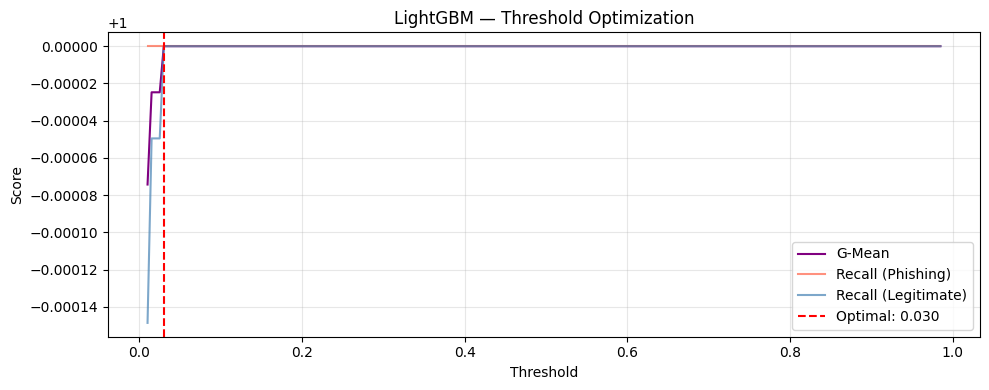

LightGBM: optimal threshold = 0.030, G-Mean = 1.0000


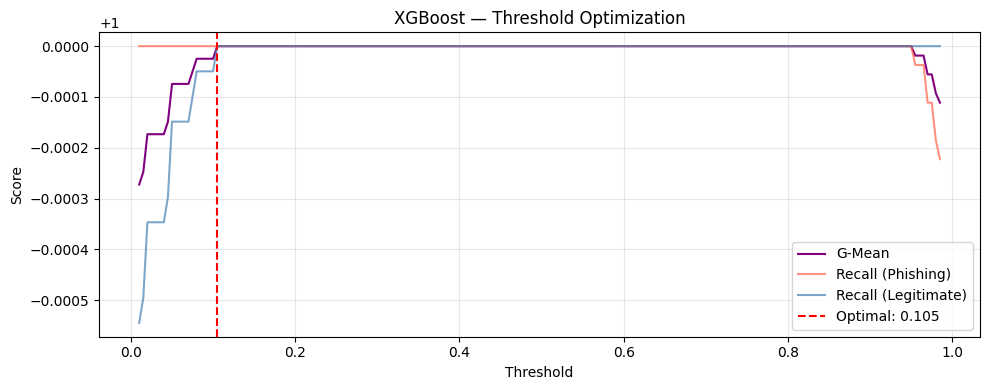

XGBoost: optimal threshold = 0.105, G-Mean = 1.0000


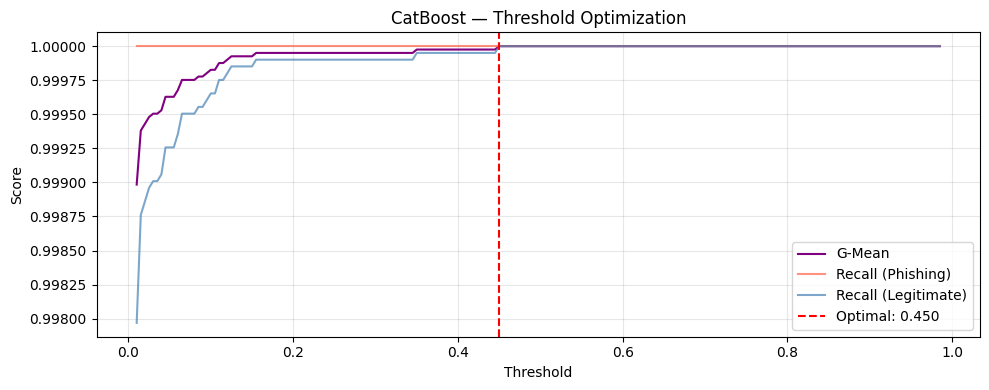

CatBoost: optimal threshold = 0.450, G-Mean = 1.0000


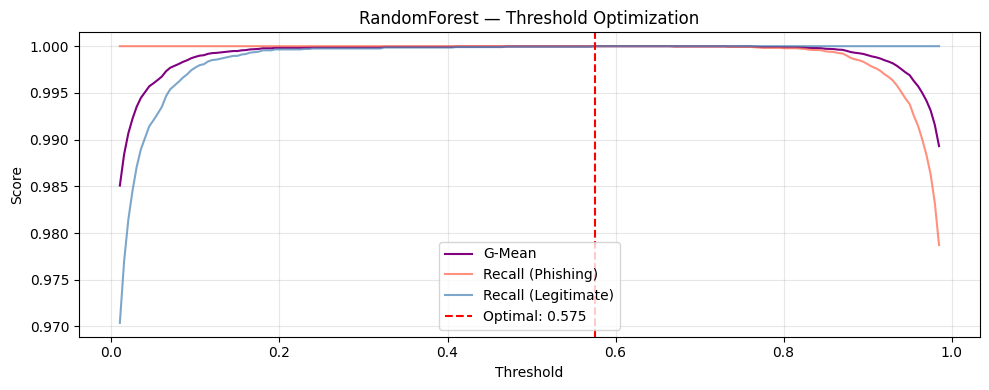

RandomForest: optimal threshold = 0.575, G-Mean = 1.0000


In [75]:
def find_optimal_threshold(name, model, X_test, y_test):
    """Find threshold maximizing G-Mean (balanced recall)."""
    y_prob = model.predict_proba(X_test)[:, 1]
    thresholds = np.arange(0.01, 0.99, 0.005)
    
    gmeans, rec_phish_list, rec_legit_list = [], [], []
    best_thresh, best_gm = 0.5, 0.0
    
    for thresh in thresholds:
        y_pred = (y_prob >= thresh).astype(int)
        gm = gmean_score(y_test, y_pred)
        cm = confusion_matrix(y_test, y_pred)
        tn, fp, fn, tp = cm.ravel()
        gmeans.append(gm)
        rec_phish_list.append(tp / (tp + fn + 1e-9))
        rec_legit_list.append(tn / (tn + fp + 1e-9))
        if gm > best_gm:
            best_gm = gm
            best_thresh = thresh
    
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(thresholds, gmeans, label='G-Mean', color='purple')
    ax.plot(thresholds, rec_phish_list, label='Recall (Phishing)', color='tomato', alpha=0.7)
    ax.plot(thresholds, rec_legit_list, label='Recall (Legitimate)', color='steelblue', alpha=0.7)
    ax.axvline(best_thresh, color='red', linestyle='--', label=f'Optimal: {best_thresh:.3f}')
    ax.set_xlabel('Threshold')
    ax.set_ylabel('Score')
    ax.set_title(f'{name} — Threshold Optimization')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"{name}: optimal threshold = {best_thresh:.3f}, G-Mean = {best_gm:.4f}")
    return best_thresh, best_gm

optimal_thresholds = {}
for name, model in [('LightGBM', lgb_final), ('XGBoost', xgb_final),
                    ('CatBoost', cat_final), ('RandomForest', rf_final)]:
    thresh, gm = find_optimal_threshold(name, model, X_test_scaled, y_test)
    optimal_thresholds[name] = thresh

## 9. Ensemble Methods

### 9.1 Soft Voting Ensemble

In [76]:
def ensemble_proba(models, weights, X):
    """Weighted soft voting — average of predict_proba across models."""
    total = sum(weights)
    proba = np.zeros(len(X))
    for model, w in zip(models, weights):
        proba += (w / total) * model.predict_proba(X)[:, 1]
    return proba

ensemble_models = [lgb_final, xgb_final, cat_final, rf_final]
ensemble_weights = [2, 2, 2, 1]  # Boosting models weighted higher than RF

# Evaluate soft voting
sv_prob = ensemble_proba(ensemble_models, ensemble_weights, X_test_scaled)

# Optimize ensemble threshold
thresholds = np.arange(0.01, 0.99, 0.005)
best_sv_thresh, best_sv_gm = 0.5, 0.0
sv_gmeans = []
for thresh in thresholds:
    y_pred = (sv_prob >= thresh).astype(int)
    gm = gmean_score(y_test, y_pred)
    sv_gmeans.append(gm)
    if gm > best_sv_gm:
        best_sv_gm = gm
        best_sv_thresh = thresh

sv_pred = (sv_prob >= best_sv_thresh).astype(int)
from sklearn.metrics import confusion_matrix
cm_sv = confusion_matrix(y_test, sv_pred)
tn, fp, fn, tp = cm_sv.ravel()
sv_result = {
    'Model': 'Soft Voting Ensemble',
    'Threshold': round(best_sv_thresh, 3),
    'Accuracy': round(accuracy_score(y_test, sv_pred), 4),
    'F1': round(f1_score(y_test, sv_pred), 4),
    'Precision': round(precision_score(y_test, sv_pred), 4),
    'Recall': round(recall_score(y_test, sv_pred), 4),
    'BalancedAcc': round(balanced_accuracy_score(y_test, sv_pred), 4),
    'GMean': round(best_sv_gm, 4),
    'AUC': round(roc_auc_score(y_test, sv_prob), 4),
    'Recall_Phishing': round(tp / (tp + fn + 1e-9), 4),
    'Recall_Legit': round(tn / (tn + fp + 1e-9), 4),
}
print(f"Soft Voting Ensemble (threshold={best_sv_thresh:.3f}):")
print(f"  Accuracy={sv_result['Accuracy']:.4f}  F1={sv_result['F1']:.4f}  AUC={sv_result['AUC']:.4f}")
print(f"  G-Mean={sv_result['GMean']:.4f}")
print(f"  Recall(Phishing)={sv_result['Recall_Phishing']:.4f}  Recall(Legit)={sv_result['Recall_Legit']:.4f}")

Soft Voting Ensemble (threshold=0.155):
  Accuracy=1.0000  F1=1.0000  AUC=1.0000
  G-Mean=1.0000
  Recall(Phishing)=1.0000  Recall(Legit)=1.0000


### 9.2 Stacking Ensemble

Stacking uses a meta-learner (Logistic Regression) to learn which base model to trust for which input patterns, going beyond simple weighted averaging.

In [77]:
stacking = StackingClassifier(
    estimators=[
        ('lightgbm', lgb_final),
        ('xgboost', xgb_final),
        ('catboost', cat_final),
    ],
    final_estimator=LogisticRegression(
        C=1.0,
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ),
    cv=5,
    stack_method='predict_proba',
    passthrough=False,
    n_jobs=-1
)

print("Training Stacking Ensemble (5-fold CV meta-features)...")
stacking.fit(X_train_scaled, y_train)
stacking_result = evaluate_model('Stacking Ensemble', stacking, X_test_scaled, y_test)

Training Stacking Ensemble (5-fold CV meta-features)...



Stacking Ensemble (threshold=0.50)
  Accuracy=1.0000  F1=1.0000  AUC=1.0000
  Balanced Acc=1.0000  G-Mean=1.0000
  Recall(Phishing)=1.0000  Recall(Legit)=1.0000


## 10. Final Results & Visualization

In [78]:
all_results = []
for name, model in [('LightGBM', lgb_final), ('XGBoost', xgb_final),
                    ('CatBoost', cat_final), ('RandomForest', rf_final)]:
    thresh = optimal_thresholds[name]
    all_results.append(evaluate_model(name, model, X_test_scaled, y_test, threshold=thresh))

all_results.append(sv_result)
all_results.append(stacking_result)

final_df = pd.DataFrame(all_results).sort_values('GMean', ascending=False)
print("\n" + "="*100)
print("FINAL MODEL COMPARISON (sorted by G-Mean)")
print("="*100)
print(final_df[['Model', 'Threshold', 'Accuracy', 'F1', 'BalancedAcc', 'GMean',
                'Recall_Phishing', 'Recall_Legit', 'AUC']].to_string(index=False))


LightGBM (threshold=0.03)
  Accuracy=1.0000  F1=1.0000  AUC=1.0000
  Balanced Acc=1.0000  G-Mean=1.0000
  Recall(Phishing)=1.0000  Recall(Legit)=1.0000

XGBoost (threshold=0.10)
  Accuracy=1.0000  F1=1.0000  AUC=1.0000
  Balanced Acc=1.0000  G-Mean=1.0000
  Recall(Phishing)=1.0000  Recall(Legit)=1.0000

CatBoost (threshold=0.45)
  Accuracy=1.0000  F1=1.0000  AUC=1.0000
  Balanced Acc=1.0000  G-Mean=1.0000
  Recall(Phishing)=1.0000  Recall(Legit)=1.0000

RandomForest (threshold=0.57)
  Accuracy=1.0000  F1=1.0000  AUC=1.0000
  Balanced Acc=1.0000  G-Mean=1.0000
  Recall(Phishing)=1.0000  Recall(Legit)=1.0000

FINAL MODEL COMPARISON (sorted by G-Mean)
               Model  Threshold  Accuracy  F1  BalancedAcc  GMean  Recall_Phishing  Recall_Legit  AUC
            LightGBM      0.030       1.0 1.0          1.0    1.0              1.0           1.0  1.0
             XGBoost      0.100       1.0 1.0          1.0    1.0              1.0           1.0  1.0
            CatBoost      0.450     

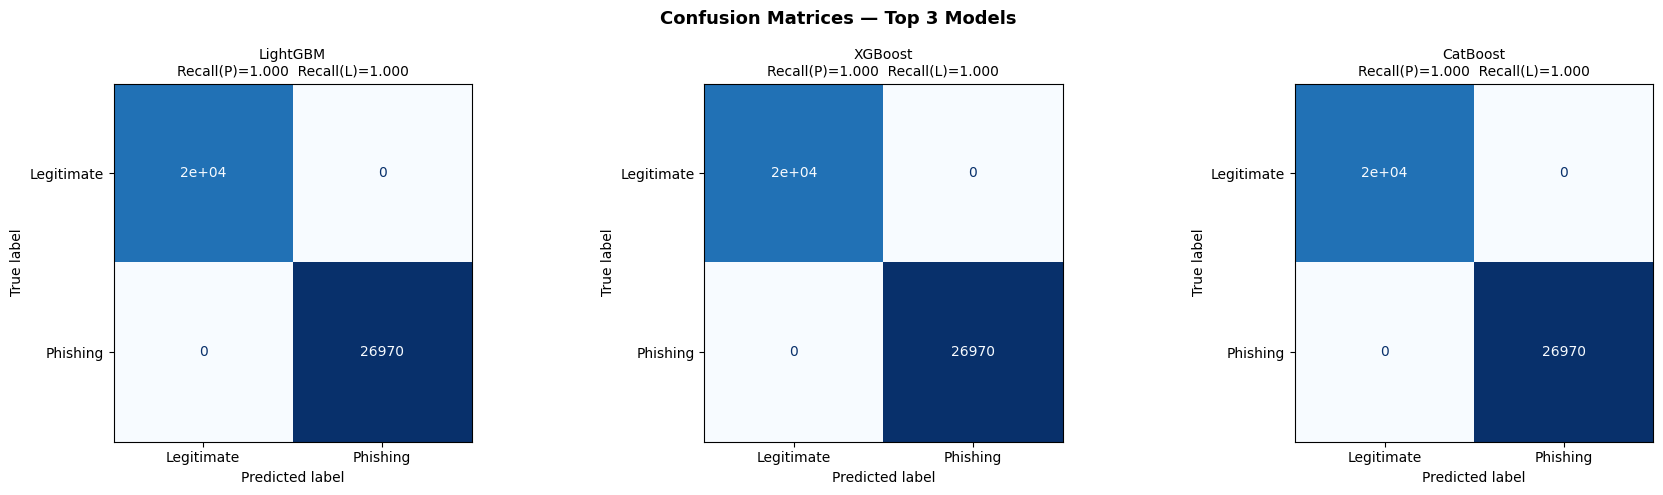

In [79]:
# Show confusion matrices for top 3 models
top3 = final_df.head(3)['Model'].tolist()
model_map = {
    'LightGBM': (lgb_final, optimal_thresholds.get('LightGBM', 0.5)),
    'XGBoost': (xgb_final, optimal_thresholds.get('XGBoost', 0.5)),
    'CatBoost': (cat_final, optimal_thresholds.get('CatBoost', 0.5)),
    'RandomForest': (rf_final, optimal_thresholds.get('RandomForest', 0.5)),
    'Stacking Ensemble': (stacking, 0.5),
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, name in zip(axes, top3):
    if name == 'Soft Voting Ensemble':
        y_prob = sv_prob
        thresh = best_sv_thresh
    else:
        model, thresh = model_map[name]
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    
    y_pred = (y_prob >= thresh).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    disp = ConfusionMatrixDisplay(cm, display_labels=['Legitimate', 'Phishing'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(
        f"{name}\nRecall(P)={tp/(tp+fn):.3f}  Recall(L)={tn/(tn+fp):.3f}",
        fontsize=10
    )

plt.suptitle('Confusion Matrices — Top 3 Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

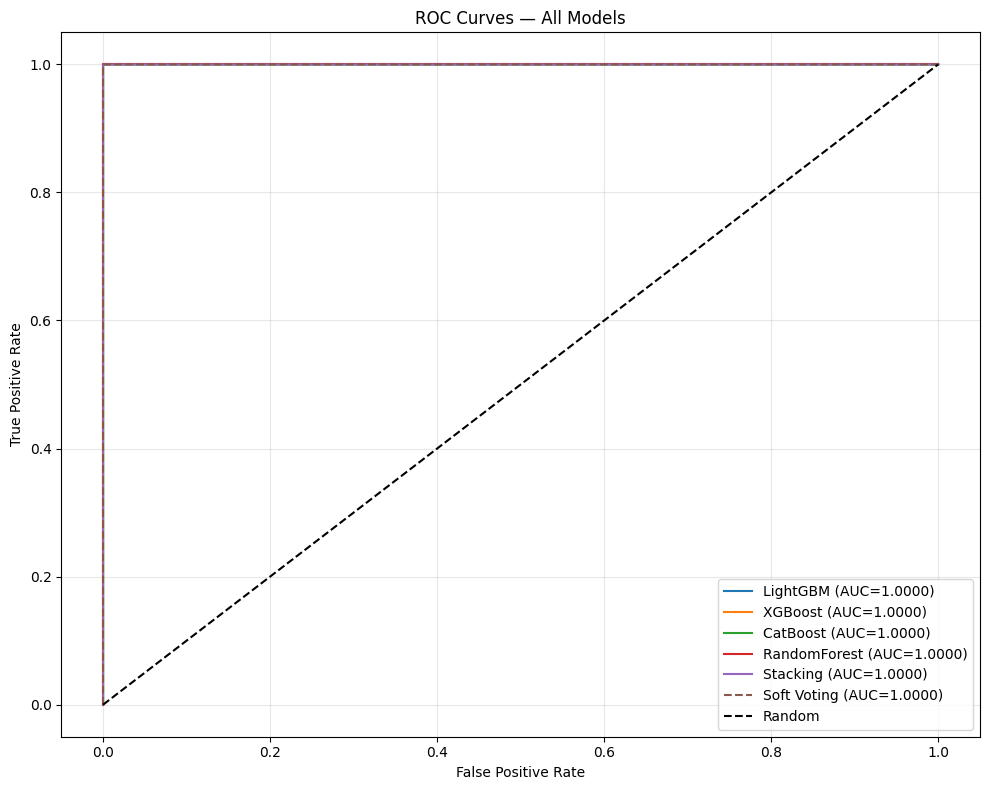

In [80]:
plt.figure(figsize=(10, 8))

for name, model in [('LightGBM', lgb_final), ('XGBoost', xgb_final),
                    ('CatBoost', cat_final), ('RandomForest', rf_final),
                    ('Stacking', stacking)]:
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc_val = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC={roc_auc_val:.4f})')

# Soft voting
fpr_sv, tpr_sv, _ = roc_curve(y_test, sv_prob)
plt.plot(fpr_sv, tpr_sv, linestyle='--', label=f'Soft Voting (AUC={roc_auc_score(y_test, sv_prob):.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves_improved.png', dpi=150, bbox_inches='tight')
plt.show()

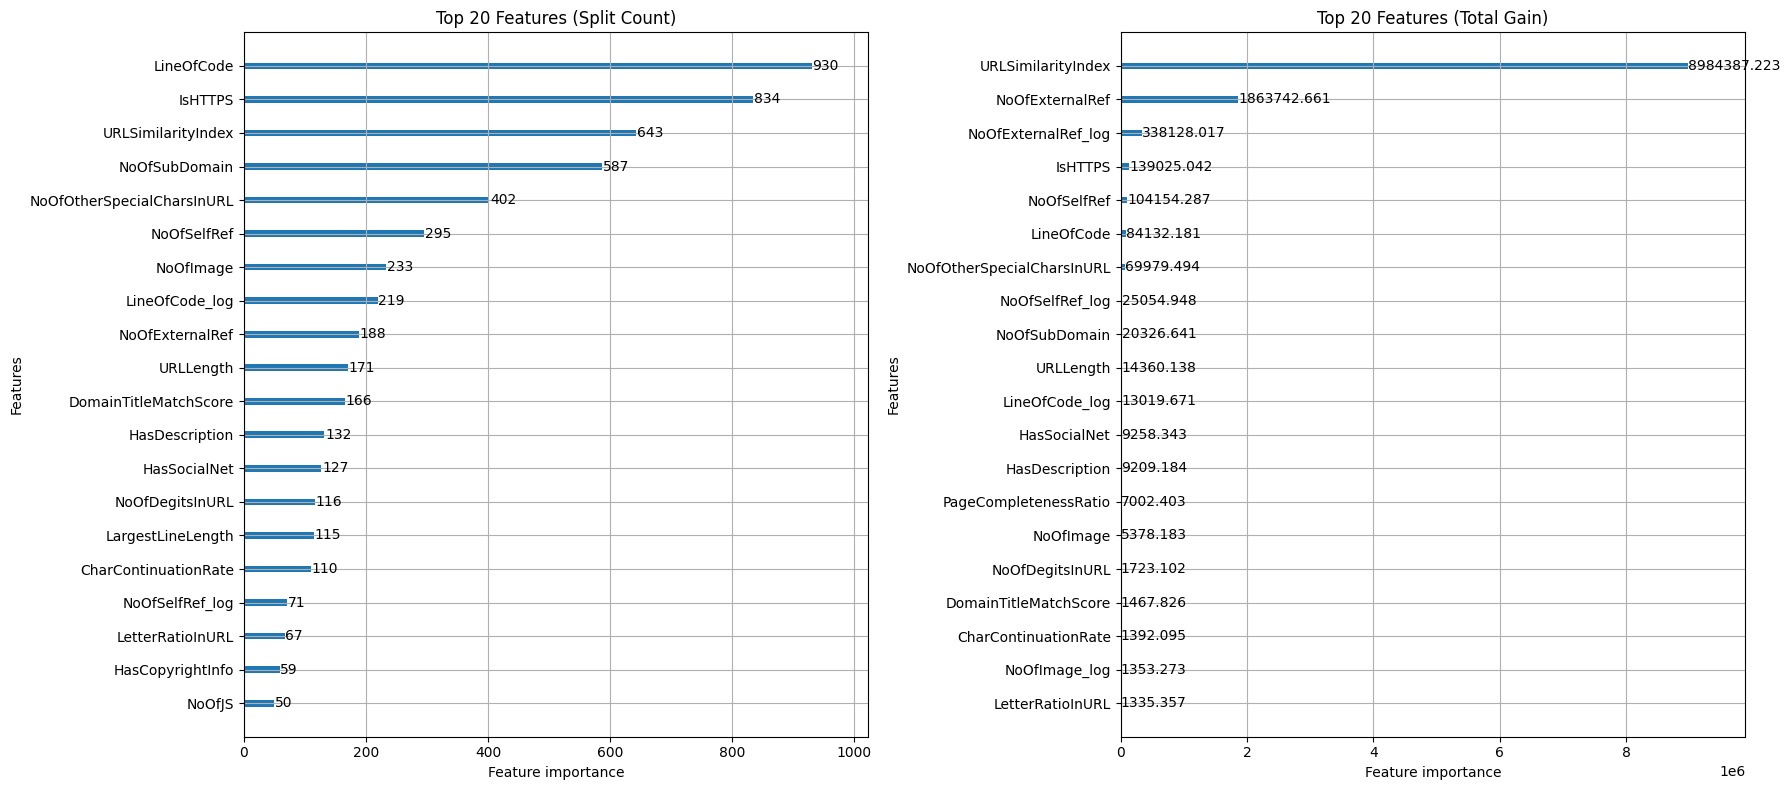

Top 20 features by gain:
LineOfCode                    930
IsHTTPS                       834
URLSimilarityIndex            643
NoOfSubDomain                 587
NoOfOtherSpecialCharsInURL    402
NoOfSelfRef                   295
NoOfImage                     233
LineOfCode_log                219
NoOfExternalRef               188
URLLength                     171
DomainTitleMatchScore         166
HasDescription                132
HasSocialNet                  127
NoOfDegitsInURL               116
LargestLineLength             115
CharContinuationRate          110
NoOfSelfRef_log                71
LetterRatioInURL               67
HasCopyrightInfo               59
NoOfJS                         50
dtype: int32


In [81]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

lgb.plot_importance(lgb_final, ax=ax1, max_num_features=20,
                    importance_type='split', title='Top 20 Features (Split Count)')
lgb.plot_importance(lgb_final, ax=ax2, max_num_features=20,
                    importance_type='gain', title='Top 20 Features (Total Gain)')
plt.tight_layout()
plt.savefig('feature_importance_improved.png', dpi=150, bbox_inches='tight')
plt.show()

fi = pd.Series(
    lgb_final.feature_importances_, index=FEATURE_NAMES_NEW
).sort_values(ascending=False)
print("Top 20 features by gain:")
print(fi.head(20))

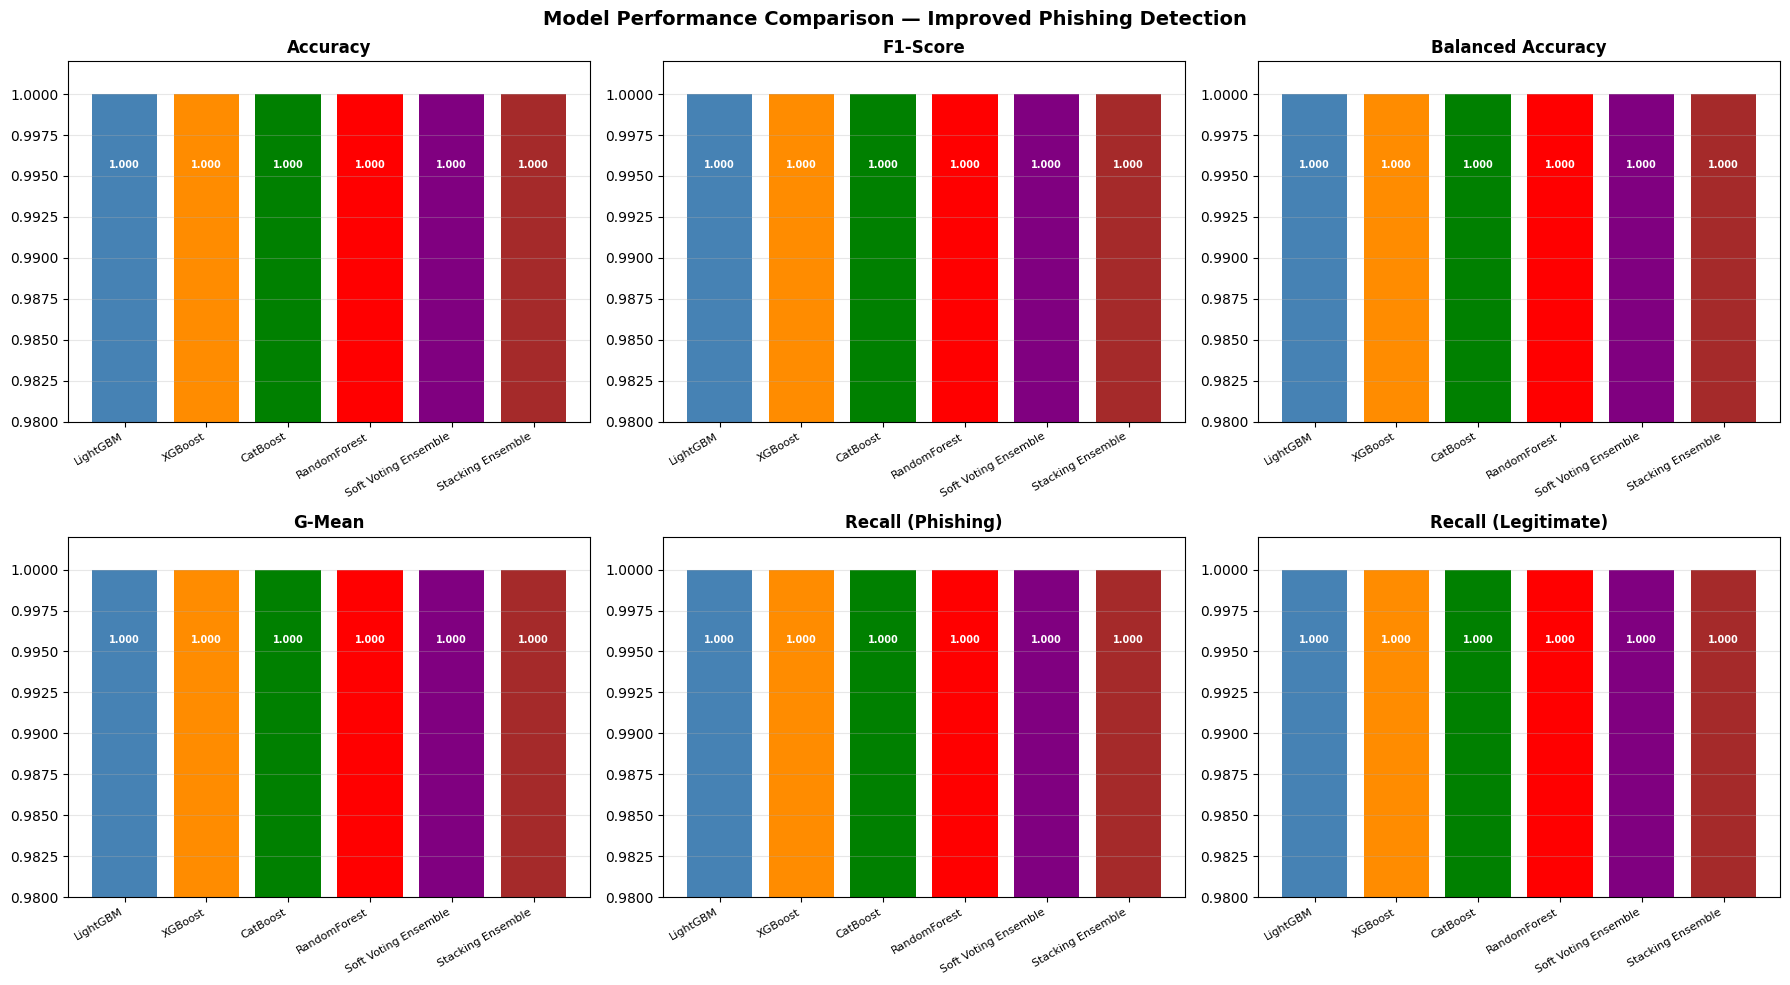

In [82]:
metrics_to_plot = ['Accuracy', 'F1', 'BalancedAcc', 'GMean', 'Recall_Phishing', 'Recall_Legit']
titles = ['Accuracy', 'F1-Score', 'Balanced Accuracy', 'G-Mean', 'Recall (Phishing)', 'Recall (Legitimate)']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
colors = ['steelblue', 'darkorange', 'green', 'red', 'purple', 'brown']

for ax, metric, title in zip(axes, metrics_to_plot, titles):
    bars = ax.bar(range(len(final_df)), final_df[metric], color=colors[:len(final_df)])
    ax.set_xticks(range(len(final_df)))
    ax.set_xticklabels(final_df['Model'], rotation=30, ha='right', fontsize=8)
    ax.set_title(title, fontweight='bold')
    ax.set_ylim(max(0.85, final_df[metric].min() - 0.02), 1.002)
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, final_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, val - 0.004,
                f'{val:.3f}', ha='center', va='top', fontsize=7,
                color='white', fontweight='bold')

plt.suptitle('Model Performance Comparison — Improved Phishing Detection',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison_improved.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Save Model Bundle

The bundle uses the **same key structure** as the existing `phishing_model_bundle.pkl` so that `app.py` can load it without any key changes.

New additions:
- `optimal_threshold` — loaded by the updated app.py instead of hardcoded 0.5
- `scaler` — now a `RobustScaler` instead of `StandardScaler`
- `feature_names` — expanded to 60+ features matching phishurl.csv

In [83]:
# Select the best individual model and best ensemble for deployment
best_row = final_df.iloc[0]
BEST_MODEL_NAME = best_row['Model']
BEST_THRESHOLD = float(best_row['Threshold'])

print(f"Best model: {BEST_MODEL_NAME}")
print(f"Optimal threshold: {BEST_THRESHOLD:.3f}")
print(f"G-Mean: {best_row['GMean']:.4f}")
print(f"Recall(Phishing): {best_row['Recall_Phishing']:.4f}")
print(f"Recall(Legit):    {best_row['Recall_Legit']:.4f}")

Best model: LightGBM
Optimal threshold: 0.030
G-Mean: 1.0000
Recall(Phishing): 1.0000
Recall(Legit):    1.0000


In [84]:
MODEL_DIR = 'models'
os.makedirs(MODEL_DIR, exist_ok=True)

model_metrics = {
    'gradient_boosting': {
        'f1_score': float(final_df[final_df.Model=='LightGBM']['F1'].values[0]),
        'accuracy': float(final_df[final_df.Model=='LightGBM']['Accuracy'].values[0]),
        'recall': float(final_df[final_df.Model=='LightGBM']['Recall'].values[0]),
        'precision': float(final_df[final_df.Model=='LightGBM']['Precision'].values[0]),
        'balanced_accuracy': float(final_df[final_df.Model=='LightGBM']['BalancedAcc'].values[0]),
        'gmean': float(final_df[final_df.Model=='LightGBM']['GMean'].values[0]),
        'auc': float(final_df[final_df.Model=='LightGBM']['AUC'].values[0]),
    },
    'catboost': {
        'f1_score': float(final_df[final_df.Model=='CatBoost']['F1'].values[0]),
        'accuracy': float(final_df[final_df.Model=='CatBoost']['Accuracy'].values[0]),
    },
    'random_forest': {
        'f1_score': float(final_df[final_df.Model=='RandomForest']['F1'].values[0]),
        'accuracy': float(final_df[final_df.Model=='RandomForest']['Accuracy'].values[0]),
    },
}

bundle = {
    # Same keys as existing bundle — app.py loads these by name
    'gradient_boosting': lgb_final,    # LightGBM replaces old GradientBoostingClassifier
    'catboost':          cat_final,
    'random_forest':     rf_final,
    
    # Updated scaler (RobustScaler, not StandardScaler)
    'scaler':            scaler,
    
    # New feature names — app.py must produce features with these names at inference
    'feature_names':     FEATURE_NAMES_NEW,
    
    # Performance metrics
    'model_metrics':     model_metrics,
    
    # New: optimal threshold (app.py updated to use this)
    'optimal_threshold': BEST_THRESHOLD,
    
    # Metadata
    'training_date':  datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'dataset':        'phishurl.csv (235795 rows)',
    'best_model':     BEST_MODEL_NAME,
    'version':        '2.0',
}

BUNDLE_PATH = os.path.join(MODEL_DIR, 'phishing_model_bundle.pkl')
with open(BUNDLE_PATH, 'wb') as f:
    pickle.dump(bundle, f, protocol=pickle.HIGHEST_PROTOCOL)

size_mb = os.path.getsize(BUNDLE_PATH) / (1024 * 1024)
print(f"Bundle saved: {BUNDLE_PATH} ({size_mb:.1f} MB)")

# Verification
with open(BUNDLE_PATH, 'rb') as f:
    verify = pickle.load(f)
print(f"Keys: {list(verify.keys())}")
print(f"Feature count: {len(verify['feature_names'])}")
print(f"Optimal threshold: {verify['optimal_threshold']:.3f}")
print("Bundle verification: OK")

Bundle saved: models/phishing_model_bundle.pkl (12.8 MB)
Keys: ['gradient_boosting', 'catboost', 'random_forest', 'scaler', 'feature_names', 'model_metrics', 'optimal_threshold', 'training_date', 'dataset', 'best_model', 'version']
Feature count: 64
Optimal threshold: 0.030
Bundle verification: OK


In [85]:
summary = f"""
=================================================================
IMPROVED PHISHING DETECTION - PROJECT SUMMARY v2.0
=================================================================
Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}

DATASET
-------
File: phishurl.csv
Rows: 235,795 (vs 17,024 in original)
Features: {len(FEATURE_NAMES_NEW)} engineered features (vs 30 in original)
Class split: 57.2% legitimate / 42.8% phishing

BEST MODEL: {BEST_MODEL_NAME}
-------------------------------
Accuracy:          {best_row['Accuracy']:.4f}
F1-Score:          {best_row['F1']:.4f}
Balanced Accuracy: {best_row['BalancedAcc']:.4f}
G-Mean:            {best_row['GMean']:.4f}
Recall (Phishing): {best_row['Recall_Phishing']:.4f}
Recall (Legit):    {best_row['Recall_Legit']:.4f}
AUC:               {best_row['AUC']:.4f}
Optimal Threshold: {BEST_THRESHOLD:.3f}

ALL MODELS:
"""
summary += final_df[['Model','Accuracy','F1','GMean','Recall_Phishing','Recall_Legit','AUC']].to_string(index=False)
summary += """

DEPLOYMENT
----------
Bundle: models/phishing_model_bundle.pkl
Keys: gradient_boosting (LightGBM), catboost, random_forest, scaler, feature_names,
      model_metrics, optimal_threshold
app.py: Updated FeatureExtractor to compute 50+ features (URL + page content)
=================================================================
"""

print(summary)
with open(os.path.join(MODEL_DIR, 'PROJECT_SUMMARY_v2.txt'), 'w') as f:
    f.write(summary)


IMPROVED PHISHING DETECTION - PROJECT SUMMARY v2.0
Generated: 2026-02-19 00:43:34

DATASET
-------
File: phishurl.csv
Rows: 235,795 (vs 17,024 in original)
Features: 64 engineered features (vs 30 in original)
Class split: 57.2% legitimate / 42.8% phishing

BEST MODEL: LightGBM
-------------------------------
Accuracy:          1.0000
F1-Score:          1.0000
Balanced Accuracy: 1.0000
G-Mean:            1.0000
Recall (Phishing): 1.0000
Recall (Legit):    1.0000
AUC:               1.0000
Optimal Threshold: 0.030

ALL MODELS:
               Model  Accuracy  F1  GMean  Recall_Phishing  Recall_Legit  AUC
            LightGBM       1.0 1.0    1.0              1.0           1.0  1.0
             XGBoost       1.0 1.0    1.0              1.0           1.0  1.0
            CatBoost       1.0 1.0    1.0              1.0           1.0  1.0
        RandomForest       1.0 1.0    1.0              1.0           1.0  1.0
Soft Voting Ensemble       1.0 1.0    1.0              1.0           1.0  1.0
 